# Install Dependencies

In [1]:
!pip install prophet boto3 pandas matplotlib plotly -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.3 MB/s eta 0:00:00


# Imports

In [2]:
import pandas as pd
import numpy as np
import boto3
import io
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from datetime import datetime

#Loading Athena CSV


In [3]:
df = pd.read_csv("/forecast_ecommerece.csv")

df = df.rename(columns={"ds": "ds", "y": "y"})
df["ds"] = pd.to_datetime(df["ds"])
df["y"]  = pd.to_numeric(df["y"])

df = df.sort_values("ds").reset_index(drop=True)

print(f"Loaded {len(df)} days of data")
print(f" Date range: {df['ds'].min().date()} → {df['ds'].max().date()}")
print(f"Avg daily revenue: ₹{df['y'].mean():,.2f}")
print(df.head(10))

Loaded 30 days of data
 Date range: 2026-02-16 → 2026-03-17
Avg daily revenue: ₹58,236.88
          ds          y
0 2026-02-16   27541.48
1 2026-02-17   26471.14
2 2026-02-18   14260.39
3 2026-02-19   70635.86
4 2026-02-20  109551.63
5 2026-02-21   86769.13
6 2026-02-22   65983.02
7 2026-02-23  134386.45
8 2026-02-24   47962.09
9 2026-02-25   39194.11


# Plotting raw data

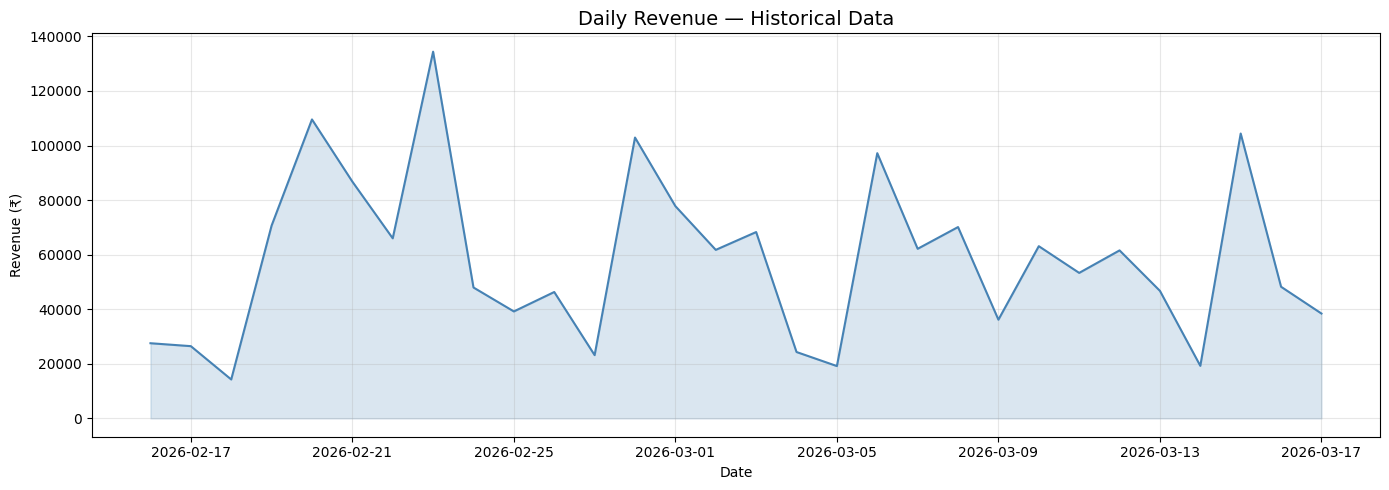

Historical plot saved!


In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df["ds"], df["y"], color="steelblue", linewidth=1.5)
plt.fill_between(df["ds"], df["y"], alpha=0.2, color="steelblue")
plt.title("Daily Revenue — Historical Data", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("historical_revenue.png", dpi=150)
plt.show()
print("Historical plot saved!")


# Train Prophet model

In [5]:
model = Prophet(
    yearly_seasonality  = False,  # not enough data for yearly
    weekly_seasonality  = True,   # detect weekend patterns
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05,  # flexibility of trend
    interval_width      = 0.95    # 95% confidence interval
)

# Add Indian holidays/sale events as custom seasonality
model.add_seasonality(
    name   = "month_end_effect",
    period = 30.5,
    fourier_order = 3
)

model.fit(df)
print("Prophet model trained successfully!")

INFO:prophet:n_changepoints greater than number of observations. Using 23.


Prophet model trained successfully!


# Make forecast for the next 30 days

In [6]:
future   = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast_clean = forecast[[
    "ds", "yhat", "yhat_lower", "yhat_upper",
    "trend", "weekly"
]].copy()

forecast_clean.columns = [
    "date", "predicted_revenue",
    "lower_bound", "upper_bound",
    "trend", "weekly_effect"
]

for col in ["predicted_revenue", "lower_bound", "upper_bound", "trend"]:
    forecast_clean[col] = forecast_clean[col].round(2)

print(f"Forecast generated for {len(future)} days")
print("Next 30 days forecast:")
print(forecast_clean.tail(30)[["date", "predicted_revenue", "lower_bound", "upper_bound"]].to_string(index=False))

Forecast generated for 60 days
Next 30 days forecast:
      date  predicted_revenue  lower_bound  upper_bound
2026-03-18           34819.61    -10413.74     77742.67
2026-03-19           67630.64     22484.61    111951.62
2026-03-20          107573.51     62028.73    153637.14
2026-03-21          126437.06     86040.69    167790.07
2026-03-22          154396.28    108505.44    194920.15
2026-03-23          154761.17    114729.58    202052.67
2026-03-24          138531.17     94320.92    182567.30
2026-03-25          112098.02     70596.30    154370.16
2026-03-26          117477.00     73888.05    163563.35
2026-03-27          127155.59     81791.19    172103.90
2026-03-28          119484.84     76022.18    164912.25
2026-03-29          129601.79     86075.58    173840.08
2026-03-30          122893.26     79939.71    165070.80
2026-03-31          109253.76     66009.62    152200.16
2026-04-01           91523.38     49862.29    135880.95
2026-04-02          107171.38     66508.48    1491

# Plot forecast

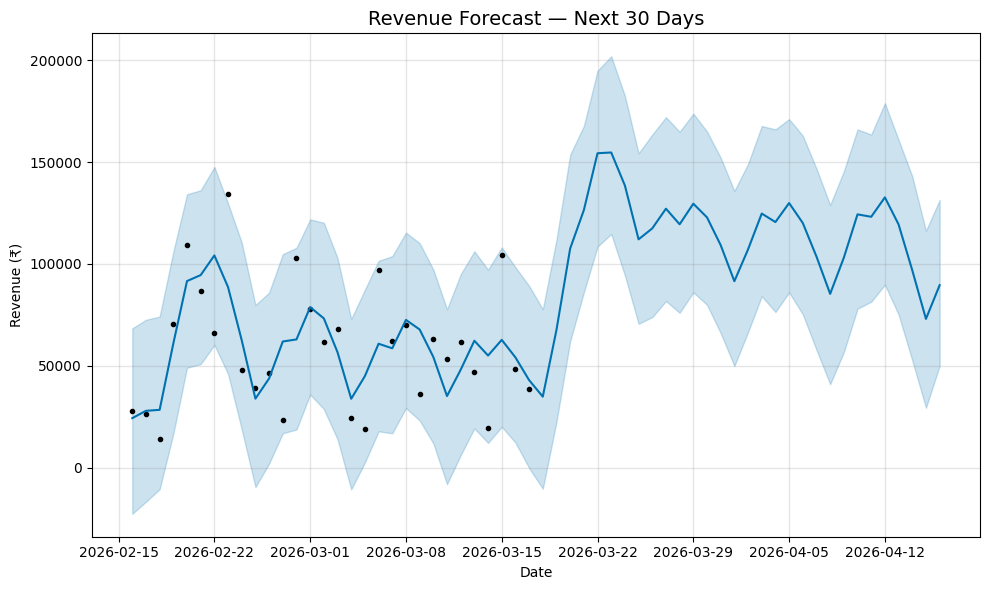

Forecast plot saved!


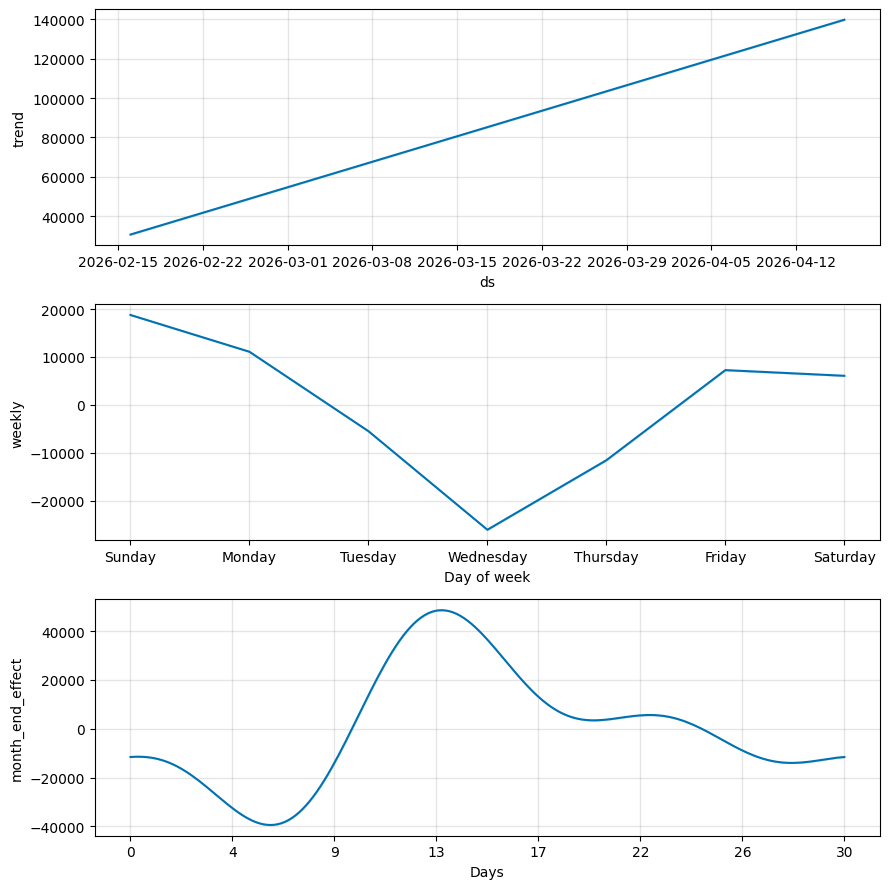

Components plot saved!


In [7]:
fig1 = model.plot(forecast)
plt.title("Revenue Forecast — Next 30 Days", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("forecast_plot.png", dpi=150)
plt.show()
print("Forecast plot saved!")

# Plot components (trend + weekly seasonality)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig("forecast_components.png", dpi=150)
plt.show()
print("Components plot saved!")

# Save predictions to CSV

In [10]:
forecast_clean.to_csv("forecast_results.csv", index=False)
print("Saved forecast_results.csv")

# Save only future predictions (next 30 days)
future_only = forecast_clean.tail(30).copy()
future_only.to_csv("next_30_days_forecast.csv", index=False)
print("Saved next_30_days_forecast.csv")
print(f"Total predicted revenue next 30 days: ₹{future_only['predicted_revenue'].sum():,.2f}")


Saved forecast_results.csv
Saved next_30_days_forecast.csv
Total predicted revenue next 30 days: ₹3,367,445.05


# Upload predictions to S3

In [ ]:
AWS_ACCESS_KEY_ID     = "xxxxxxxxxxxxxxx"
AWS_SECRET_ACCESS_KEY = "xxxxxxxxxxxxxxxxxxxx"
AWS_REGION            = "xxxxxxxxxxxxxxxxxxx"
S3_BUCKET_NAME        = "aadhyas-first-bucket"

s3 = boto3.client(
    "s3",
    region_name           = AWS_REGION,
    aws_access_key_id     = AWS_ACCESS_KEY_ID,
    aws_secret_access_key = AWS_SECRET_ACCESS_KEY,
)

# uploading forecast results
files_to_upload = [
    ("forecast_results.csv",      "forecast/output/forecast_results.csv"),
    ("next_30_days_forecast.csv", "forecast/output/next_30_days_forecast.csv"),
    ("historical_revenue.png",    "forecast/output/historical_revenue.png"),
    ("forecast_plot.png",         "forecast/output/forecast_plot.png"),
    ("forecast_components.png",   "forecast/output/forecast_components.png"),
]

for local_file, s3_key in files_to_upload:
    s3.upload_file(local_file, S3_BUCKET_NAME, s3_key)
    print(f"Uploaded: s3://{S3_BUCKET_NAME}/{s3_key}")

print("All files uploaded to S3!")



historical_avg = df["y"].mean()
forecast_avg   = future_only["predicted_revenue"].mean()
growth         = ((forecast_avg - historical_avg) / historical_avg) * 100

print("FORECAST SUMMARY")

print(f"Historical avg daily revenue : ₹{historical_avg:,.2f}")
print(f"Forecast avg daily revenue   : ₹{forecast_avg:,.2f}")
print(f"Expected growth              : {growth:+.1f}%")
print(f"Total predicted next 30 days : ₹{future_only['predicted_revenue'].sum():,.2f}")
print(f"Best day predicted           : ₹{future_only['predicted_revenue'].max():,.2f}")
print(f"Lowest day predicted         : ₹{future_only['predicted_revenue'].min():,.2f}")
